In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt   # ← ÇA MANQUE !
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import os

In [12]:
###########################################
### Chargement et préparation des données
###########################################
df = pd.read_csv("data/city_lifestyle_dataset.csv")

# On exclu les variables catégorielles (donc city_name et country)
feature_cols = [
    'population_density', 'avg_income', 'internet_penetration', 
    'avg_rent', 'air_quality_index', 'public_transport_score', 
    'happiness_score', 'green_space_ratio'
]

X = df[feature_cols].copy()

# Pour gérer les valeurs manquantes
X = X.fillna(X.mean())

# on utilise country comme label
y = df['country']

print(f"Données préparées : {X.shape[0]} villes, {X.shape[1]} features")
print(f"Labels : {y.nunique()} pays différents")

Données préparées : 300 villes, 8 features
Labels : 6 pays différents


In [13]:
###########################################
### Normalisation (obligatoire pour t-SNE)
###########################################
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [17]:
###########################################
### Application t-SNE
###########################################
tsne = TSNE(
    n_components=2, 
    perplexity=20, 
    random_state=99, 
    max_iter=1000,
    learning_rate='auto'
)
X_tsne = tsne.fit_transform(X_scaled)

In [18]:
###########################################
### Sauvegarde des résultats
###########################################
result = pd.DataFrame(X_tsne, columns=['tSNE_1', 'tSNE_2'])
result['country'] = y.values
result['city_name'] = df['city_name'].values


print(f"KL divergence (qualité) : {tsne.kl_divergence_:.4f}")
print("\nAperçu des résultats :")
print(result.head())

KL divergence (qualité) : 0.6216

Aperçu des résultats :
      tSNE_1    tSNE_2 country      city_name
0  20.432060  8.964241  Europe      Old Vista
1  12.688293  2.509297  Europe      Beachport
2  21.722046 -4.598613  Europe  Valleyborough
3  11.156754 -5.372977  Europe           City
4  25.950550 -8.502313  Europe          Falls


On voit ici qu'on a un KL divergence = 0.62, ce qui est très bien pour t-SNE car les valeurs <1 indiquent une bonne préservation des distances locales.

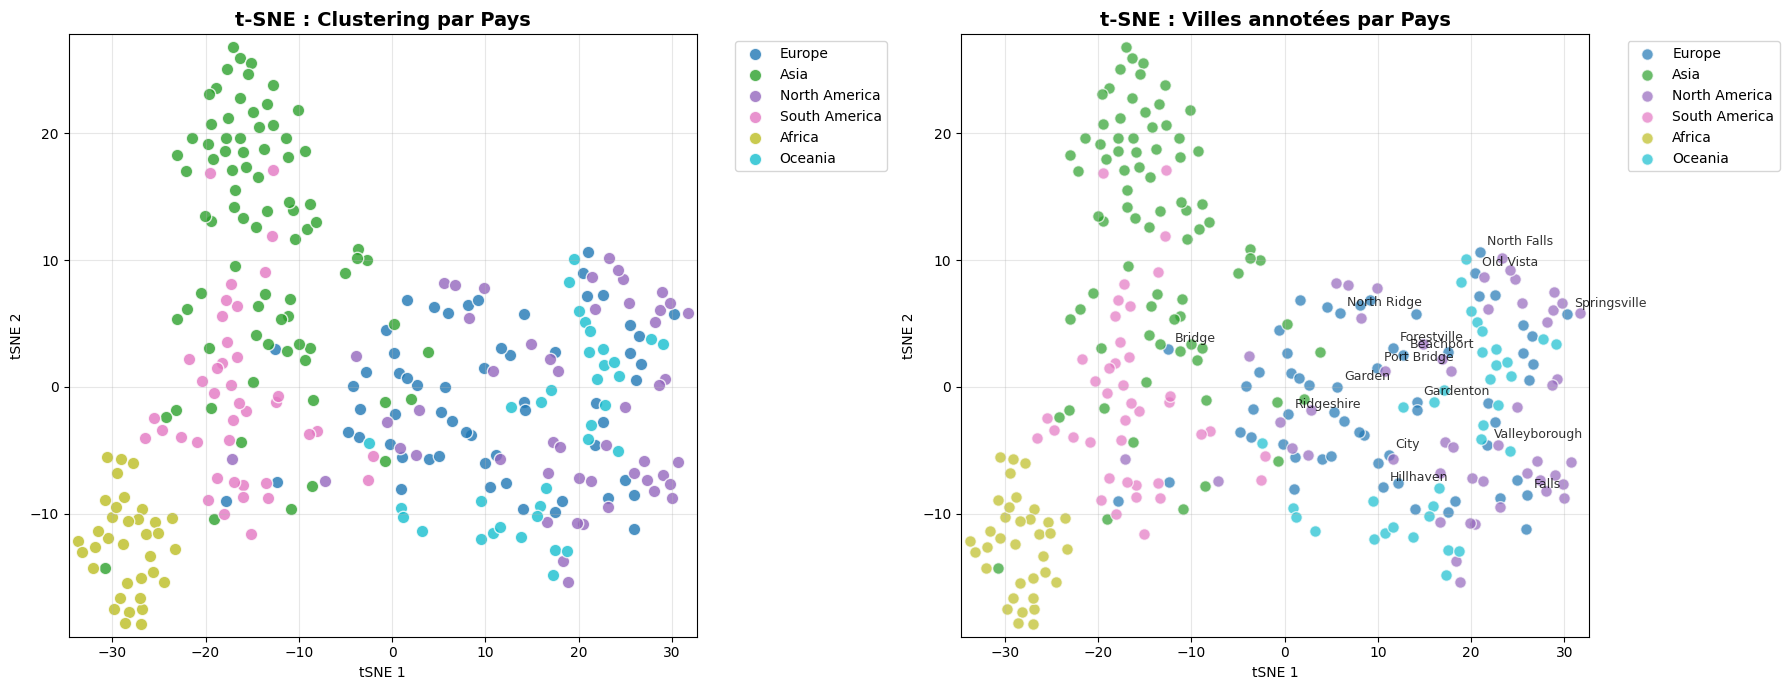

In [ ]:
###########################################
### GRAPHIQUES t-SNE
###########################################

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

pays_unique = result['country'].unique()
colors = plt.cm.tab10(np.linspace(0, 1, len(pays_unique)))
pays_couleurs = dict(zip(pays_unique, colors))

# 1 -- Clustering par pays AVEC LÉGENDE
for pays in pays_unique:
    mask = result['country'] == pays
    axes[0].scatter(result.loc[mask, 'tSNE_1'], result.loc[mask, 'tSNE_2'], 
                   c=[pays_couleurs[pays]], label=pays, alpha=0.8, s=80, edgecolor='white')

axes[0].set_title('t-SNE : Clustering par Pays', fontweight='bold', fontsize=14)
axes[0].set_xlabel('tSNE 1')
axes[0].set_ylabel('tSNE 2')
axes[0].grid(True, alpha=0.3)
axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')  # légende à droite
axes[0].set_xlim(result['tSNE_1'].min()-1, result['tSNE_1'].max()+1)
axes[0].set_ylim(result['tSNE_2'].min()-1, result['tSNE_2'].max()+1)

# 2 -- Villes annotées AVEC LÉGENDE
for pays in pays_unique:
    mask = result['country'] == pays
    axes[1].scatter(result.loc[mask, 'tSNE_1'], result.loc[mask, 'tSNE_2'], 
                   c=[pays_couleurs[pays]], label=pays, alpha=0.7, s=70, edgecolor='white')

# Affichage des 15 premières villes
for i in range(min(15, len(result))):
    axes[1].annotate(result.iloc[i]['city_name'][:15], 
                     (result.iloc[i]['tSNE_1'], result.iloc[i]['tSNE_2']),
                     xytext=(5, 5), textcoords='offset points', fontsize=9, alpha=0.8)

axes[1].set_title('t-SNE : Villes annotées par Pays', fontweight='bold', fontsize=14)
axes[1].set_xlabel('tSNE 1')
axes[1].set_ylabel('tSNE 2')
axes[1].grid(True, alpha=0.3)
axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
axes[1].set_xlim(result['tSNE_1'].min()-1, result['tSNE_1'].max()+1)
axes[1].set_ylim(result['tSNE_2'].min()-1, result['tSNE_2'].max()+1)

plt.tight_layout()
plt.savefig('outputs/tsne_villes_par_pays_legende.png', dpi=300, bbox_inches='tight')
plt.show()


Ces graphiques montrent un clustering clair des villes par pays. 

Les villes d'un même pays forment des groupes distincts qu'on retrouve sous la même couleur, ce qui révèle des similarités de vie au sein des pays.

On voit par exemple l'asie en vert, qui a un groupe en haut bien distinc des autres, et également l'afrique en bas a gauche qui est également très bien separé des autres continents.

Le mode de vie des pays sont donc séparables en 2D.

In [22]:
###########################################
#### Outputs
###########################################
os.makedirs('outputs', exist_ok=True)
result = pd.DataFrame(X_tsne, columns=['tSNE_1', 'tSNE_2'])
result['country'] = y.values
result['city_name'] = df['city_name'].values
result.to_csv('outputs/tsne_result.csv', index=False)